In [16]:
import requests
import json
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:

url="https://api.openweathermap.org/data/2.5/weather"
parameters= {
    'lat': 60.45,
    'lon': -38.67,
    'appid': '3471262419c2af1e9347ffd3c9ab86aa'    
}

response = requests.get(url,params=parameters)

if response.status_code == 200:
    data = response.json()  
    print(data)
else:
    print(f"Failed to retrieve data: {response.status_code}")

{'coord': {'lon': -38.67, 'lat': 60.45}, 'weather': [{'id': 804, 'main': 'Clouds', 'description': 'overcast clouds', 'icon': '04d'}], 'base': 'stations', 'main': {'temp': 279.7, 'feels_like': 276.93, 'temp_min': 279.7, 'temp_max': 279.7, 'pressure': 998, 'humidity': 91, 'sea_level': 998, 'grnd_level': 998}, 'visibility': 10000, 'wind': {'speed': 3.97, 'deg': 316, 'gust': 5.03}, 'clouds': {'all': 100}, 'dt': 1760008511, 'sys': {'sunrise': 1760000416, 'sunset': 1760038993}, 'timezone': -10800, 'id': 0, 'name': '', 'cod': 200}


In [7]:
url="https://api.open-meteo.com/v1/forecast"
parameters= {
    "latitude": 34.0836708,
	"longitude": 74.7972825,
	"hourly": ["temperature_2m", "weather_code", "precipitation_probability", "rain", "showers", "snowfall", "visibility", "pressure_msl"],
	"past_days": 61,   
}

response = requests.get(url,params=parameters)

if response.status_code == 200:
    data = response.json()  
    print(data)
else:
    print(f"Failed to retrieve data: {response.status_code}")

{'latitude': 34.125, 'longitude': 74.75, 'generationtime_ms': 35.82608699798584, 'utc_offset_seconds': 0, 'timezone': 'GMT', 'timezone_abbreviation': 'GMT', 'elevation': 1589.0, 'hourly_units': {'time': 'iso8601', 'temperature_2m': '°C', 'weather_code': 'wmo code', 'precipitation_probability': '%', 'rain': 'mm', 'showers': 'mm', 'snowfall': 'cm', 'visibility': 'm', 'pressure_msl': 'hPa'}, 'hourly': {'time': ['2025-08-10T00:00', '2025-08-10T01:00', '2025-08-10T02:00', '2025-08-10T03:00', '2025-08-10T04:00', '2025-08-10T05:00', '2025-08-10T06:00', '2025-08-10T07:00', '2025-08-10T08:00', '2025-08-10T09:00', '2025-08-10T10:00', '2025-08-10T11:00', '2025-08-10T12:00', '2025-08-10T13:00', '2025-08-10T14:00', '2025-08-10T15:00', '2025-08-10T16:00', '2025-08-10T17:00', '2025-08-10T18:00', '2025-08-10T19:00', '2025-08-10T20:00', '2025-08-10T21:00', '2025-08-10T22:00', '2025-08-10T23:00', '2025-08-11T00:00', '2025-08-11T01:00', '2025-08-11T02:00', '2025-08-11T03:00', '2025-08-11T04:00', '2025-08

In [8]:
hourly_data = data["hourly"]
df = pd.DataFrame(hourly_data)
df.head()

,time,temperature_2m,weather_code,precipitation_probability,rain,showers,snowfall,visibility,pressure_msl
0,2025-08-10T00:00,18.1,2,0,0.0,0.0,0.0,24140.0,1006.7
1,2025-08-10T01:00,18.6,2,0,0.0,0.0,0.0,24140.0,1007.4
2,2025-08-10T02:00,21.1,2,0,0.0,0.0,0.0,24140.0,1008.1
3,2025-08-10T03:00,24.3,2,0,0.0,0.0,0.0,24140.0,1008.3
4,2025-08-10T04:00,26.0,1,5,0.0,0.0,0.0,24140.0,1007.7


In [9]:
df["latitude"] = data.get("latitude")
df["longitude"] = data.get("longitude")
df["elevation"] = data.get("elevation")
df["timezone"] = data.get("timezone")
df.head()

,time,temperature_2m,weather_code,precipitation_probability,rain,showers,snowfall,visibility,pressure_msl,latitude,longitude,elevation,timezone
0,2025-08-10T00:00,18.1,2,0,0.0,0.0,0.0,24140.0,1006.7,34.125,74.75,1589.0,GMT
1,2025-08-10T01:00,18.6,2,0,0.0,0.0,0.0,24140.0,1007.4,34.125,74.75,1589.0,GMT
2,2025-08-10T02:00,21.1,2,0,0.0,0.0,0.0,24140.0,1008.1,34.125,74.75,1589.0,GMT
3,2025-08-10T03:00,24.3,2,0,0.0,0.0,0.0,24140.0,1008.3,34.125,74.75,1589.0,GMT
4,2025-08-10T04:00,26.0,1,5,0.0,0.0,0.0,24140.0,1007.7,34.125,74.75,1589.0,GMT


In [10]:
df.shape

(1632, 13)

In [11]:
df['weather_code'].value_counts()

weather_code
0     618
2     292
1     276
3     261
61     61
80     60
95     32
63     21
45      4
96      3
81      2
65      2
Name: count, dtype: int64

In [12]:
df.to_csv("weather.csv")

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1632 entries, 0 to 1631
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   time                       1632 non-null   object 
 1   temperature_2m             1632 non-null   float64
 2   weather_code               1632 non-null   int64  
 3   precipitation_probability  1632 non-null   int64  
 4   rain                       1632 non-null   float64
 5   showers                    1632 non-null   float64
 6   snowfall                   1632 non-null   float64
 7   visibility                 1632 non-null   float64
 8   pressure_msl               1632 non-null   float64
 9   latitude                   1632 non-null   float64
 10  longitude                  1632 non-null   float64
 11  elevation                  1632 non-null   float64
 12  timezone                   1632 non-null   object 
dtypes: float64(9), int64(2), object(2)
memory usage:

In [85]:
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time')
df['hour'] = df['time'].dt.hour
df['month'] = df['time'].dt.month

In [86]:
for lag in range(1, 4):
    df[f'precipitation_lag_{lag}'] = df['precipitation_probability'].shift(lag)
    df[f'temp_lag_{lag}'] = df['temperature_2m'].shift(lag)

In [87]:
feature_cols = ['temperature_2m', 'weather_code', 'rain', 'showers', 'snowfall',
                'visibility', 'pressure_msl', 'latitude', 'longitude', 'elevation',
                'hour', 'month'] + [c for c in df.columns if 'lag' in c]
X = df[feature_cols]
y = df['precipitation_probability']

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [89]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [94]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [95]:
y_pred = rf.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [96]:
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

RMSE: 6.61
R²: 0.943


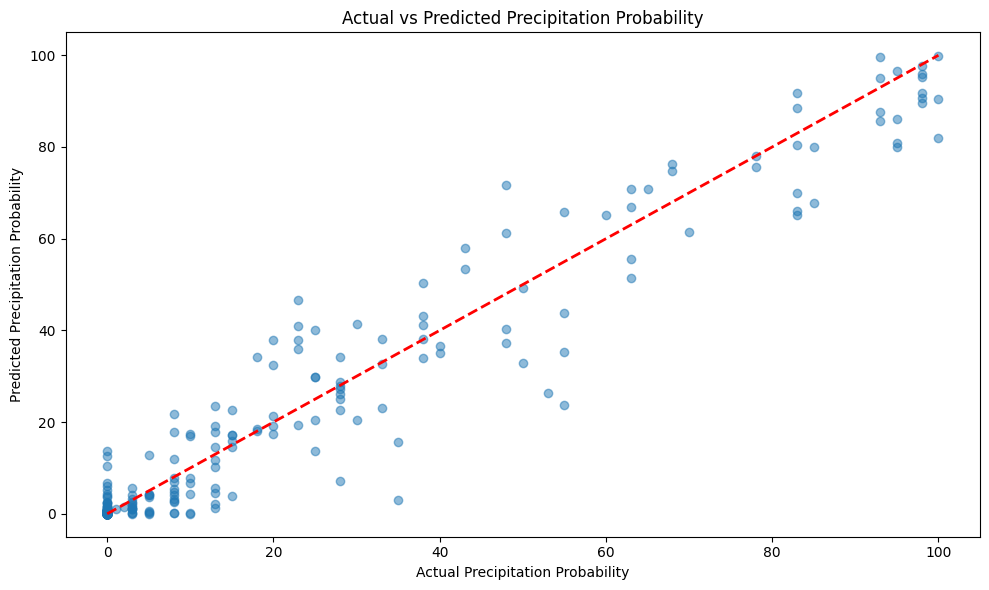

In [97]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Precipitation Probability')
plt.ylabel('Predicted Precipitation Probability')
plt.title('Actual vs Predicted Precipitation Probability')
plt.tight_layout()